<a href="https://colab.research.google.com/github/luciaPi/MLSS2026-generative-models/blob/main/2_GAN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative Adversarial Network (GAN) na MNIST

## 1. Import a príprava dát

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Používam zariadenie: {device}")

Používam zariadenie: cuda


In [ ]:
# Hyperparametre
BATCH_SIZE = 128
EPOCHS = 50
LATENT_DIM = 100
LR_G = 0.0002 # rychlost ucenia generatora
LR_D = 0.0002 # rychlost ucenia diskriminatora
BETA1 = 0.5

# Načítanie MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalizácia do [-1, 1]
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Trénovacích vzoriek: {len(train_dataset)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Počet batches: {len(train_loader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 463kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.38MB/s]

Trénovacích vzoriek: 60000
Batch size: 128
Počet batches: 468


## 2. Definícia Generátora

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            # Vstup: latent_dim (napr. 100)
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),    # nenulovy gradient (inak "zomierajuce" neurony - neucia sa)
            nn.BatchNorm1d(256),  # brani explozii gradientov -> stabilnejsi trening

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),

            nn.Linear(1024, 784),  # 28*28 = 784
            nn.Tanh()  # Výstup v [-1, 1] -> stabilnejsi trening
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 1, 28, 28)
        return img

generator = Generator(LATENT_DIM).to(device)
print("Generator:")
print(generator)
print(f"\nPočet parametrov: {sum(p.numel() for p in generator.parameters())}")

Generator:
Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)

Počet parametrov: 1489936


## 3. Definícia Diskriminátora

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            # Vstup: 784 (28*28)
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()  # Výstup: pravdepodobnosť [0, 1]
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

discriminator = Discriminator().to(device)
print("Discriminator:")
print(discriminator)
print(f"\nPočet parametrov: {sum(p.numel() for p in discriminator.parameters())}")

Discriminator:
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Počet parametrov: 533505


## 4. Loss funkcia a optimizéry

In [ ]:
# Binary Cross Entropy loss
adversarial_loss = nn.BCELoss() # pravdepodobnost, ze obrazok je pravy

# Optimizéry - samostatne pre G a D
optimizer_G = optim.Adam(generator.parameters(), lr=LR_G, betas=(BETA1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(BETA1, 0.999))

print("Loss funkcia a optimizéry pripravené!")

Loss funkcia a optimizéry pripravené!


## 5. Trénovanie GAN

ZAČÍNAM TRÉNOVANIE GAN
Epocha [1/50] | D Loss: 0.4231 | G Loss: 1.1562 | D Acc: 81.3%
Epocha [2/50] | D Loss: 0.6207 | G Loss: 0.8393 | D Acc: 65.7%
Epocha [3/50] | D Loss: 0.6270 | G Loss: 0.8571 | D Acc: 64.8%
Epocha [4/50] | D Loss: 0.6261 | G Loss: 0.8710 | D Acc: 64.9%
Epocha [5/50] | D Loss: 0.6435 | G Loss: 0.8342 | D Acc: 62.6%


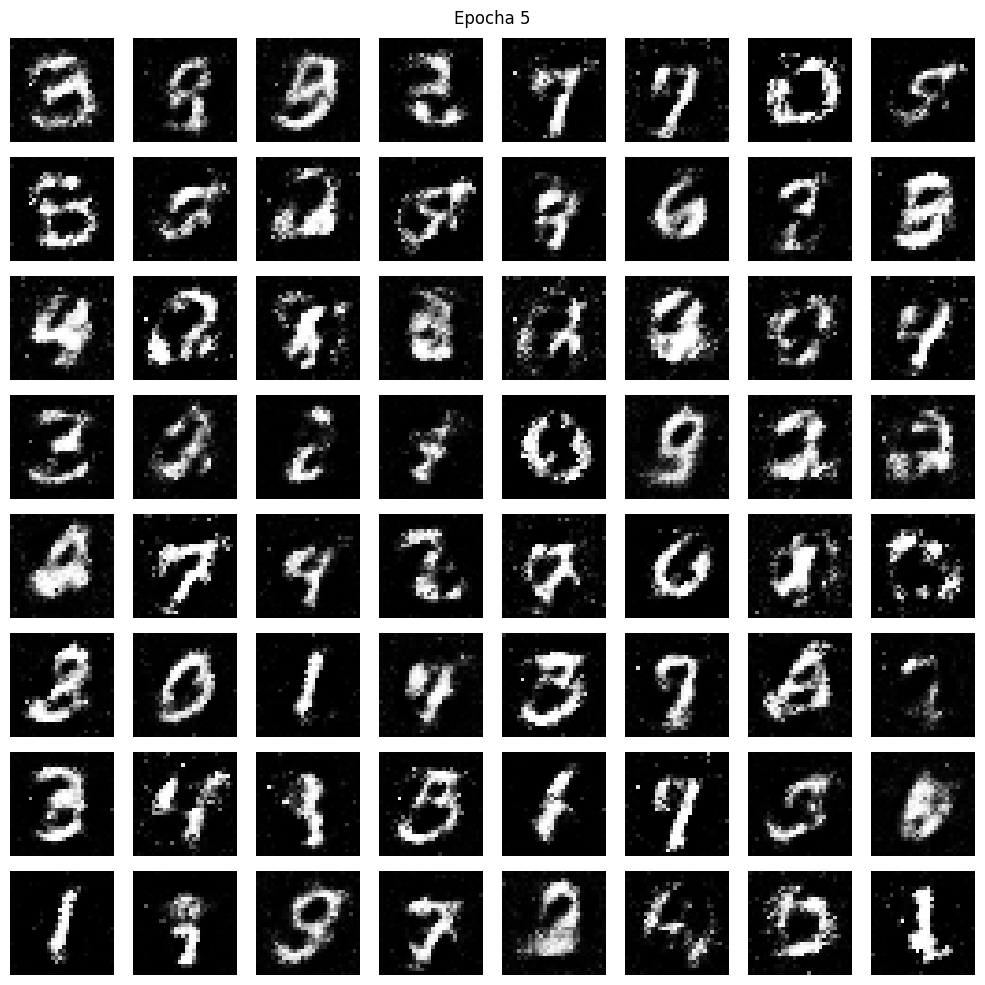

Epocha [6/50] | D Loss: 0.6537 | G Loss: 0.8019 | D Acc: 61.2%
Epocha [7/50] | D Loss: 0.6605 | G Loss: 0.7851 | D Acc: 60.3%
Epocha [8/50] | D Loss: 0.6660 | G Loss: 0.7727 | D Acc: 59.3%
Epocha [9/50] | D Loss: 0.6691 | G Loss: 0.7662 | D Acc: 58.8%
Epocha [10/50] | D Loss: 0.6722 | G Loss: 0.7600 | D Acc: 58.2%


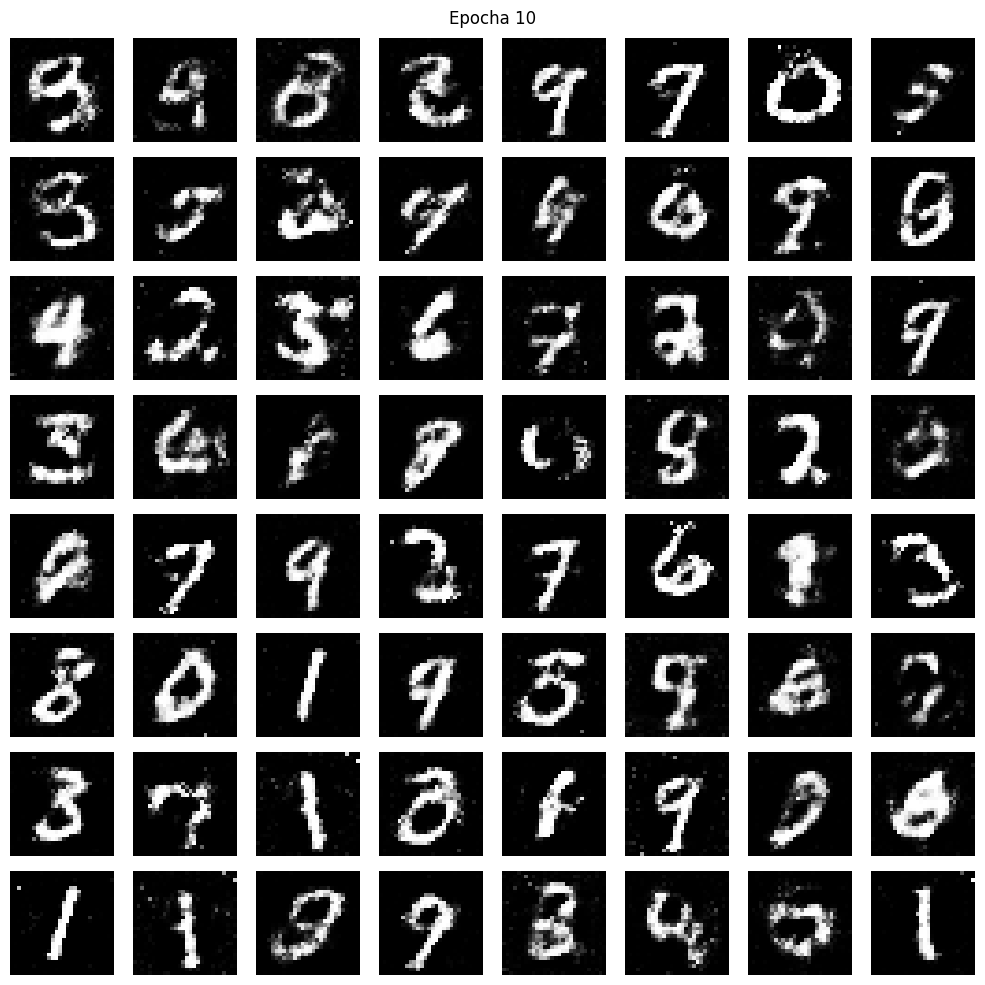

Epocha [11/50] | D Loss: 0.6749 | G Loss: 0.7530 | D Acc: 57.7%
Epocha [12/50] | D Loss: 0.6768 | G Loss: 0.7478 | D Acc: 57.1%
Epocha [13/50] | D Loss: 0.6786 | G Loss: 0.7453 | D Acc: 56.8%
Epocha [14/50] | D Loss: 0.6804 | G Loss: 0.7407 | D Acc: 56.4%
Epocha [15/50] | D Loss: 0.6799 | G Loss: 0.7418 | D Acc: 56.6%


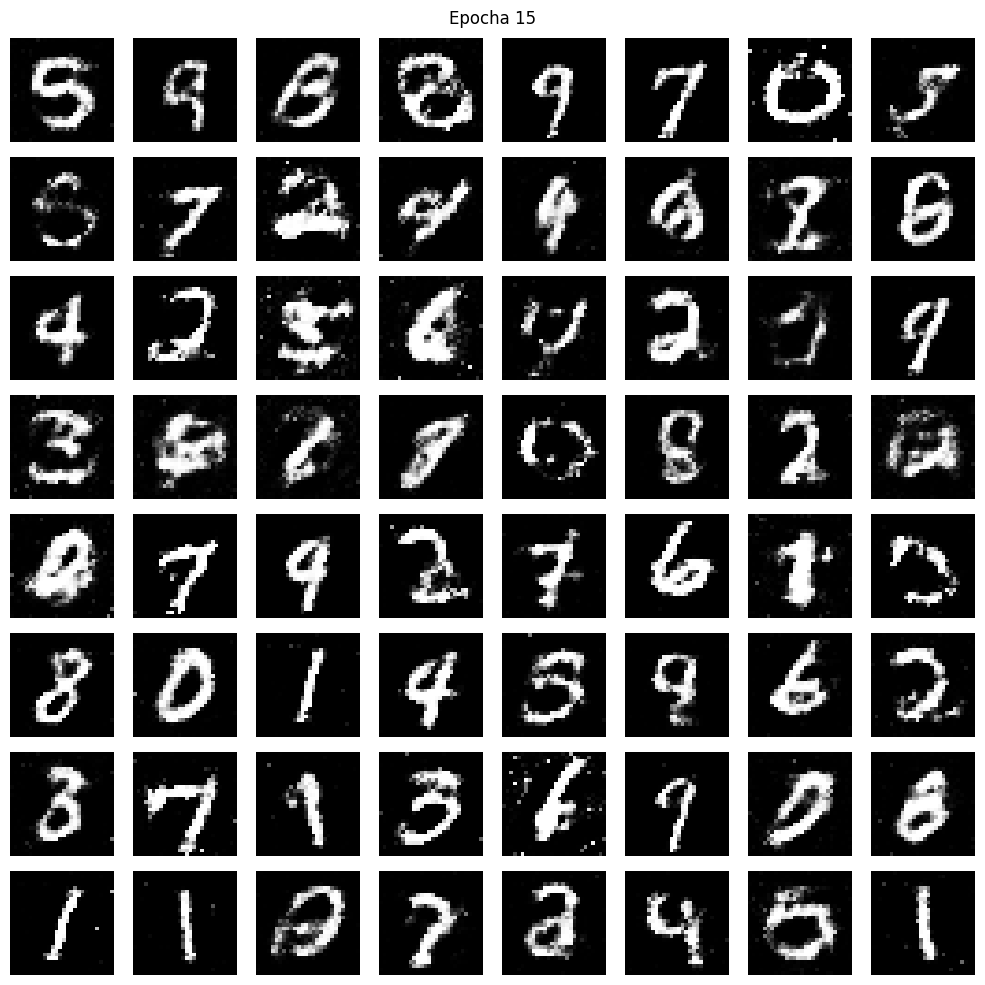

Epocha [16/50] | D Loss: 0.6804 | G Loss: 0.7414 | D Acc: 56.2%
Epocha [17/50] | D Loss: 0.6819 | G Loss: 0.7381 | D Acc: 56.1%
Epocha [18/50] | D Loss: 0.6818 | G Loss: 0.7365 | D Acc: 55.9%
Epocha [19/50] | D Loss: 0.6834 | G Loss: 0.7345 | D Acc: 55.6%
Epocha [20/50] | D Loss: 0.6832 | G Loss: 0.7329 | D Acc: 55.6%


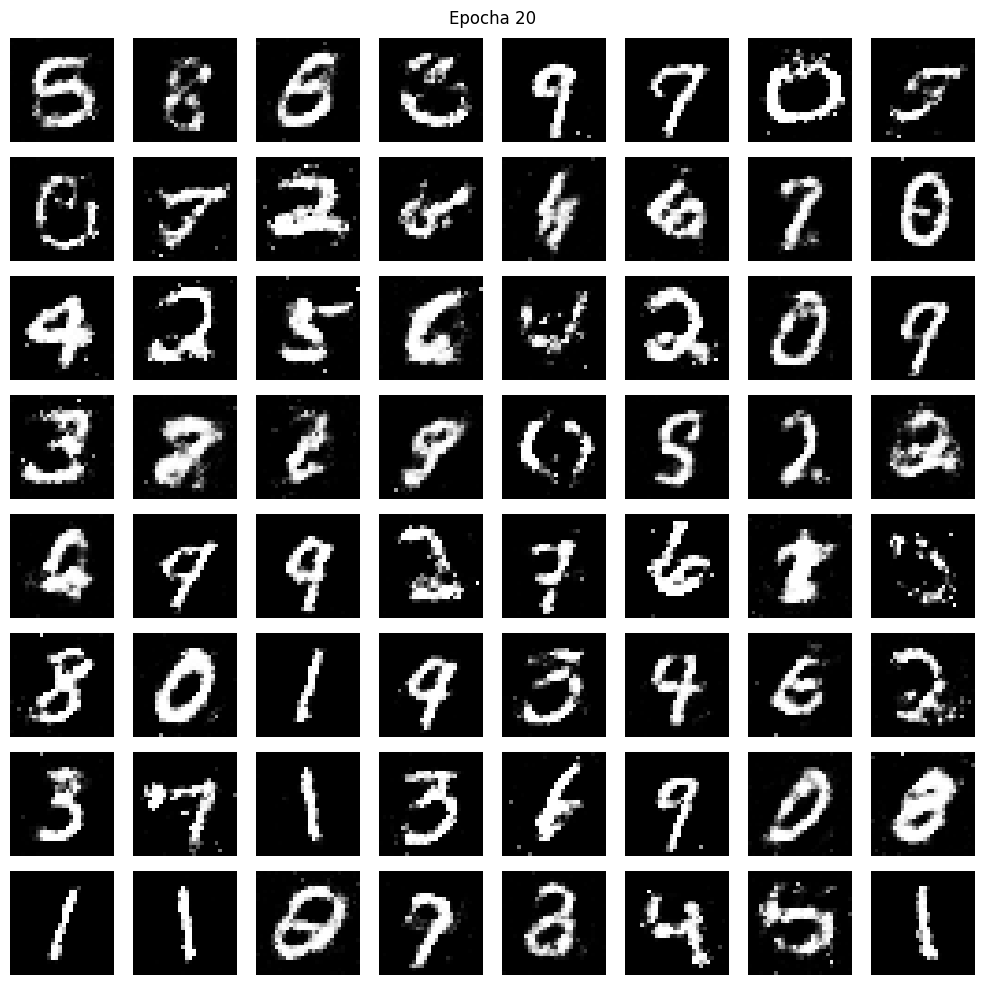

Epocha [21/50] | D Loss: 0.6828 | G Loss: 0.7326 | D Acc: 55.6%
Epocha [22/50] | D Loss: 0.6834 | G Loss: 0.7334 | D Acc: 55.5%
Epocha [23/50] | D Loss: 0.6841 | G Loss: 0.7323 | D Acc: 55.3%
Epocha [24/50] | D Loss: 0.6837 | G Loss: 0.7324 | D Acc: 55.2%
Epocha [25/50] | D Loss: 0.6837 | G Loss: 0.7307 | D Acc: 55.5%


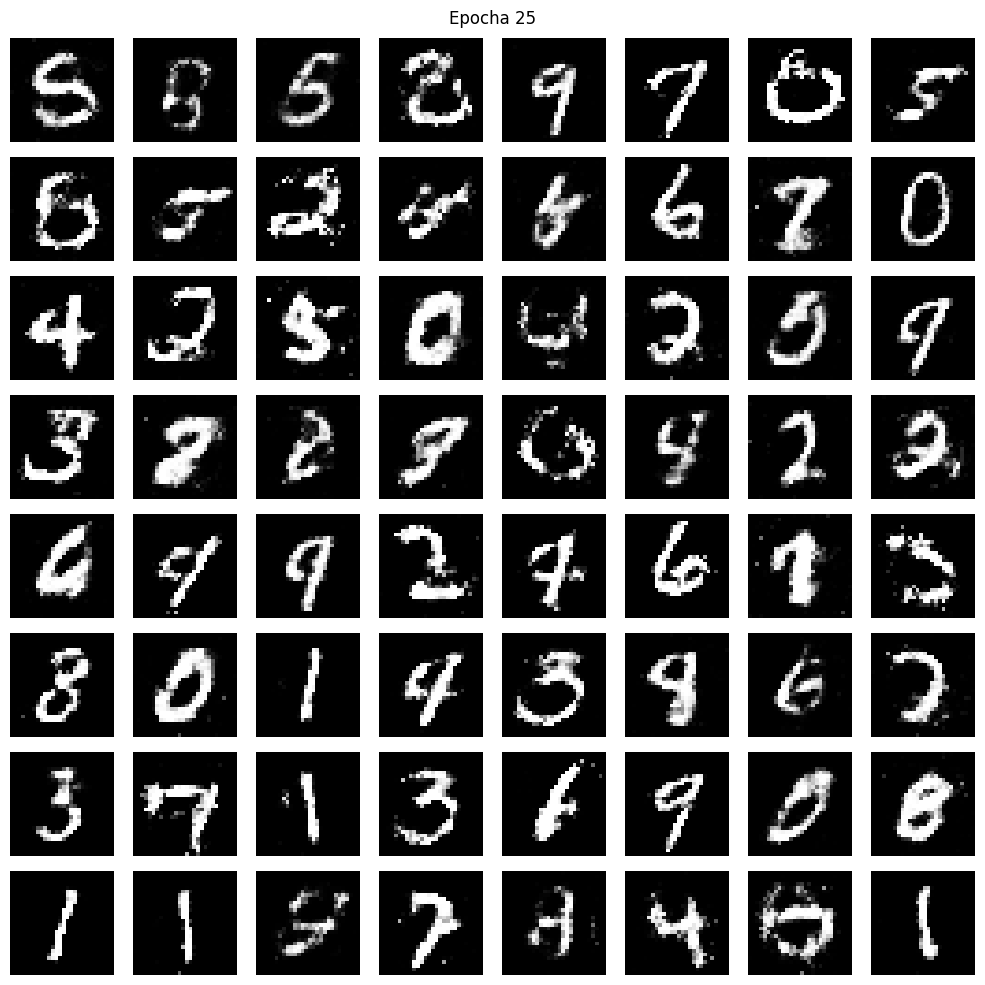

Epocha [26/50] | D Loss: 0.6841 | G Loss: 0.7320 | D Acc: 55.2%
Epocha [27/50] | D Loss: 0.6835 | G Loss: 0.7314 | D Acc: 55.5%
Epocha [28/50] | D Loss: 0.6838 | G Loss: 0.7318 | D Acc: 55.4%
Epocha [29/50] | D Loss: 0.6841 | G Loss: 0.7317 | D Acc: 55.3%
Epocha [30/50] | D Loss: 0.6841 | G Loss: 0.7288 | D Acc: 55.1%


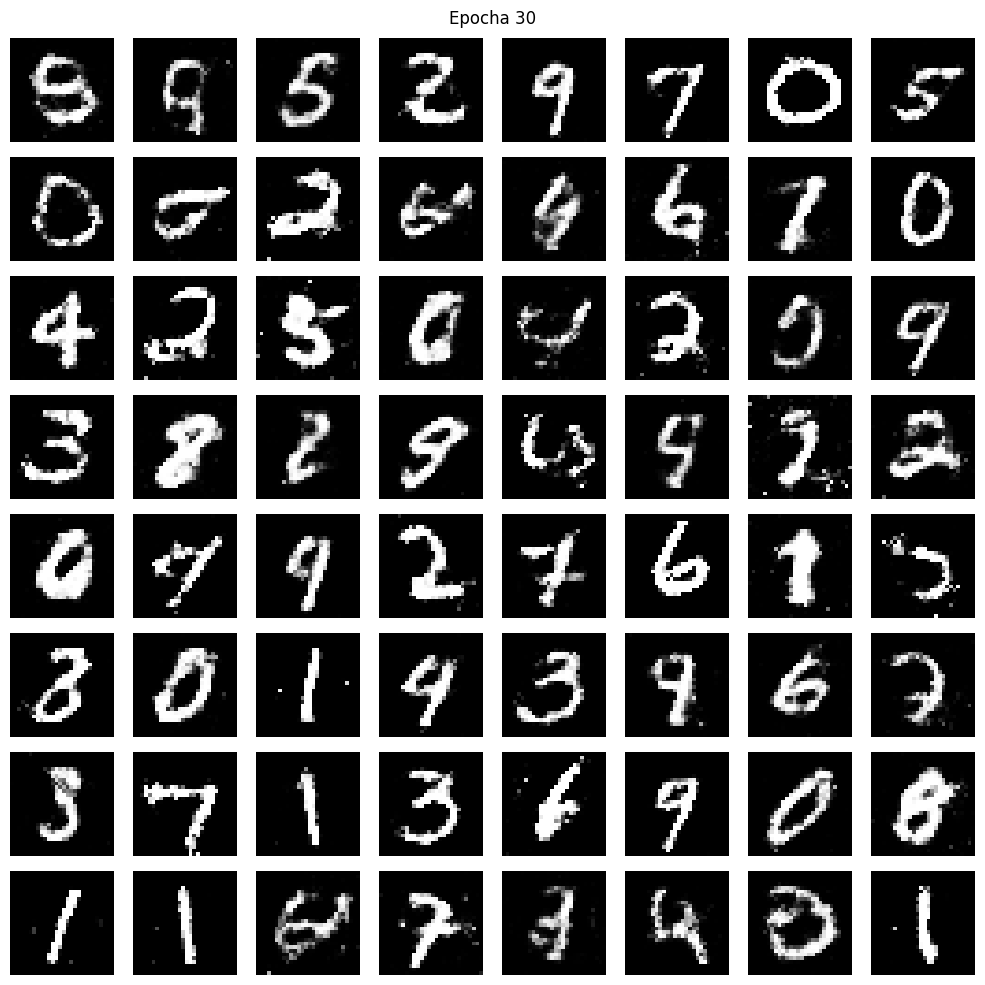

Epocha [31/50] | D Loss: 0.6848 | G Loss: 0.7291 | D Acc: 55.1%
Epocha [32/50] | D Loss: 0.6844 | G Loss: 0.7299 | D Acc: 55.1%
Epocha [33/50] | D Loss: 0.6847 | G Loss: 0.7288 | D Acc: 55.1%
Epocha [34/50] | D Loss: 0.6849 | G Loss: 0.7274 | D Acc: 55.0%
Epocha [35/50] | D Loss: 0.6854 | G Loss: 0.7279 | D Acc: 54.9%


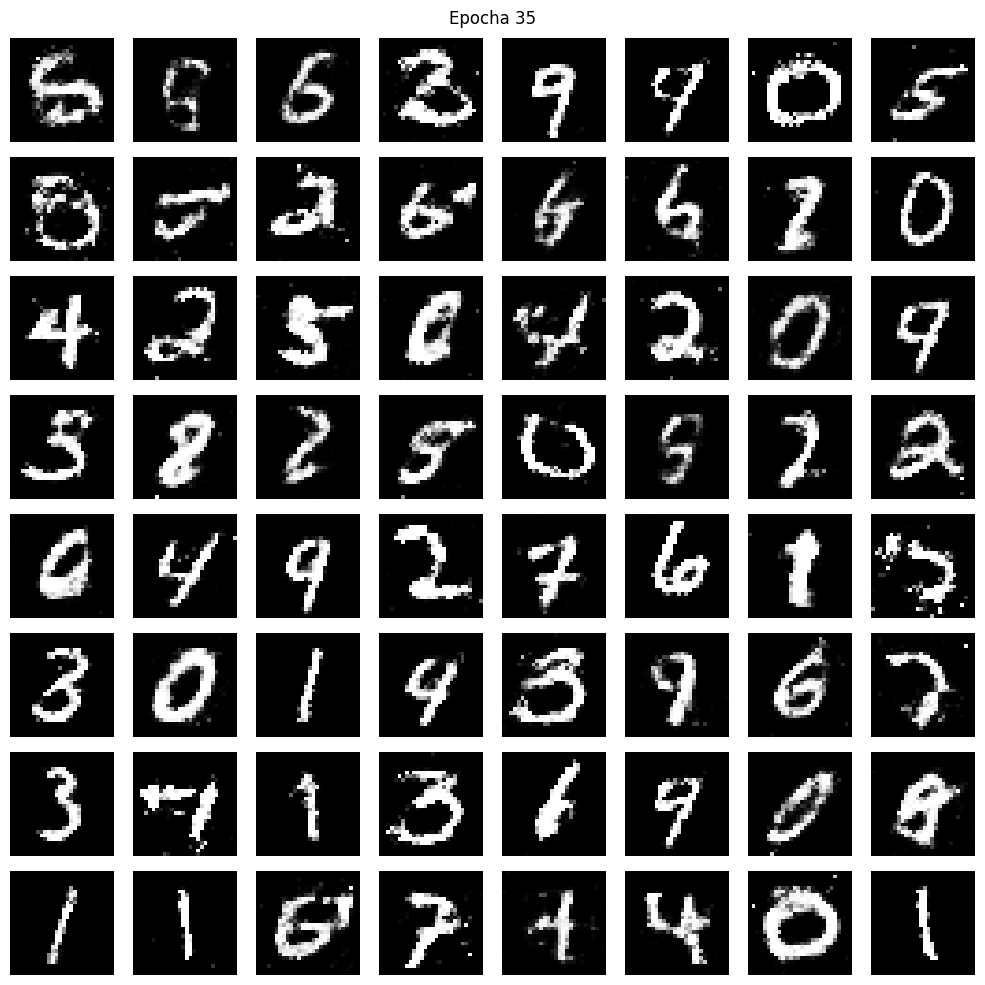

Epocha [36/50] | D Loss: 0.6847 | G Loss: 0.7292 | D Acc: 55.2%
Epocha [37/50] | D Loss: 0.6853 | G Loss: 0.7286 | D Acc: 54.8%
Epocha [38/50] | D Loss: 0.6846 | G Loss: 0.7272 | D Acc: 55.3%
Epocha [39/50] | D Loss: 0.6848 | G Loss: 0.7277 | D Acc: 55.1%
Epocha [40/50] | D Loss: 0.6851 | G Loss: 0.7256 | D Acc: 55.1%


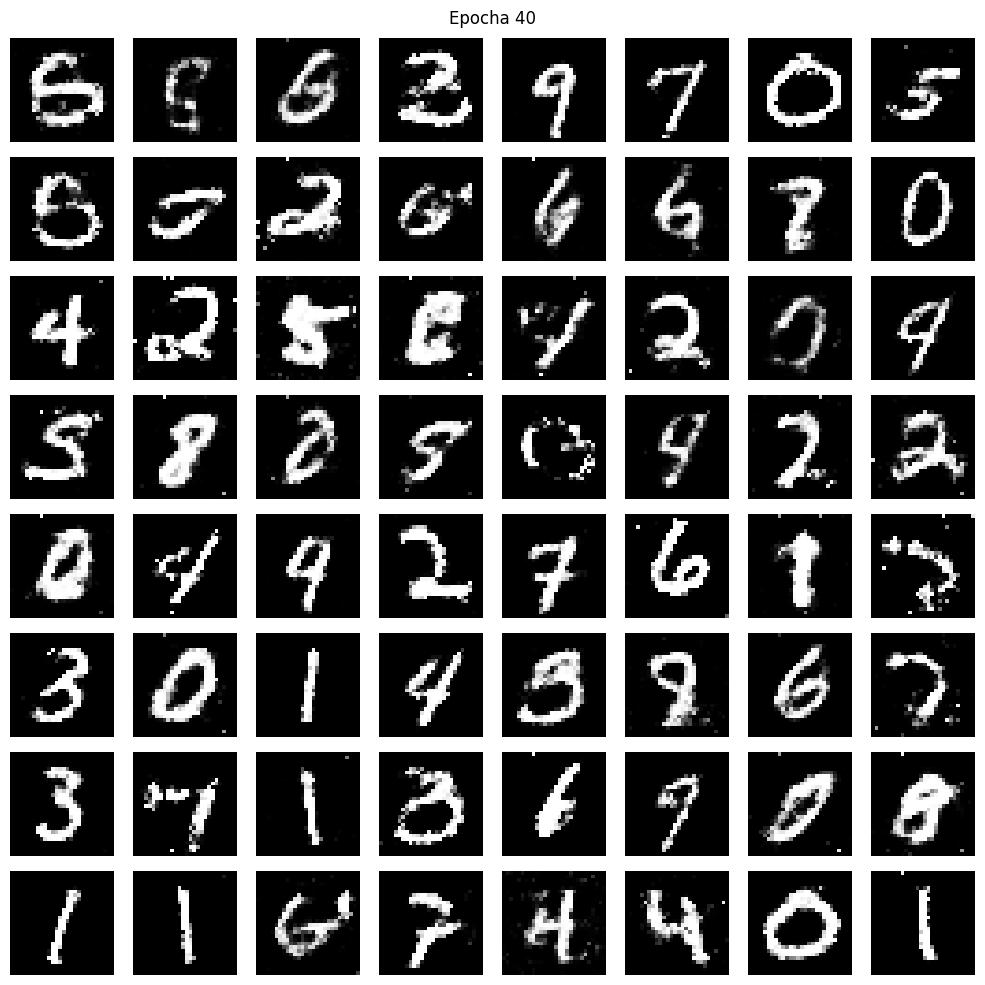

Epocha [41/50] | D Loss: 0.6852 | G Loss: 0.7245 | D Acc: 54.9%
Epocha [42/50] | D Loss: 0.6852 | G Loss: 0.7270 | D Acc: 55.0%
Epocha [43/50] | D Loss: 0.6853 | G Loss: 0.7263 | D Acc: 54.8%
Epocha [44/50] | D Loss: 0.6852 | G Loss: 0.7253 | D Acc: 54.7%
Epocha [45/50] | D Loss: 0.6853 | G Loss: 0.7258 | D Acc: 54.8%


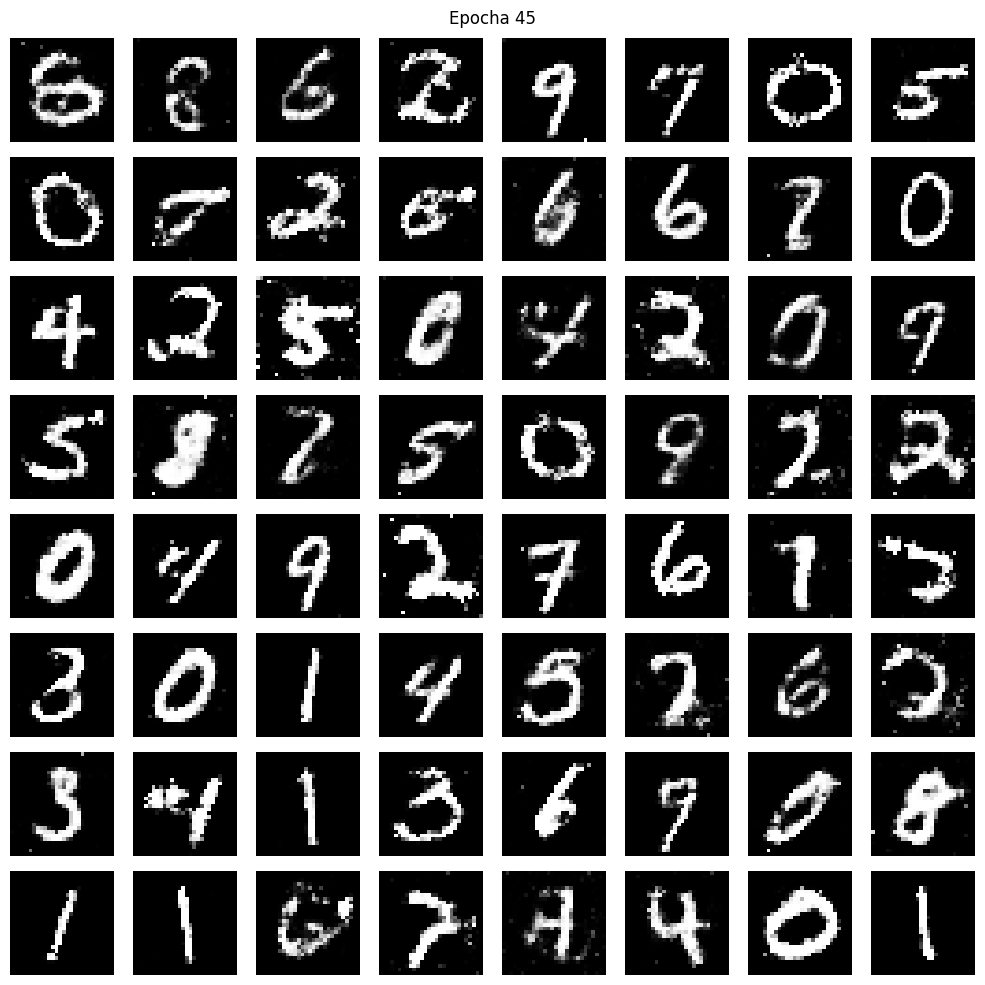

Epocha [46/50] | D Loss: 0.6850 | G Loss: 0.7250 | D Acc: 54.9%
Epocha [47/50] | D Loss: 0.6849 | G Loss: 0.7249 | D Acc: 55.0%
Epocha [48/50] | D Loss: 0.6856 | G Loss: 0.7249 | D Acc: 54.8%
Epocha [49/50] | D Loss: 0.6852 | G Loss: 0.7247 | D Acc: 55.0%
Epocha [50/50] | D Loss: 0.6852 | G Loss: 0.7261 | D Acc: 55.0%


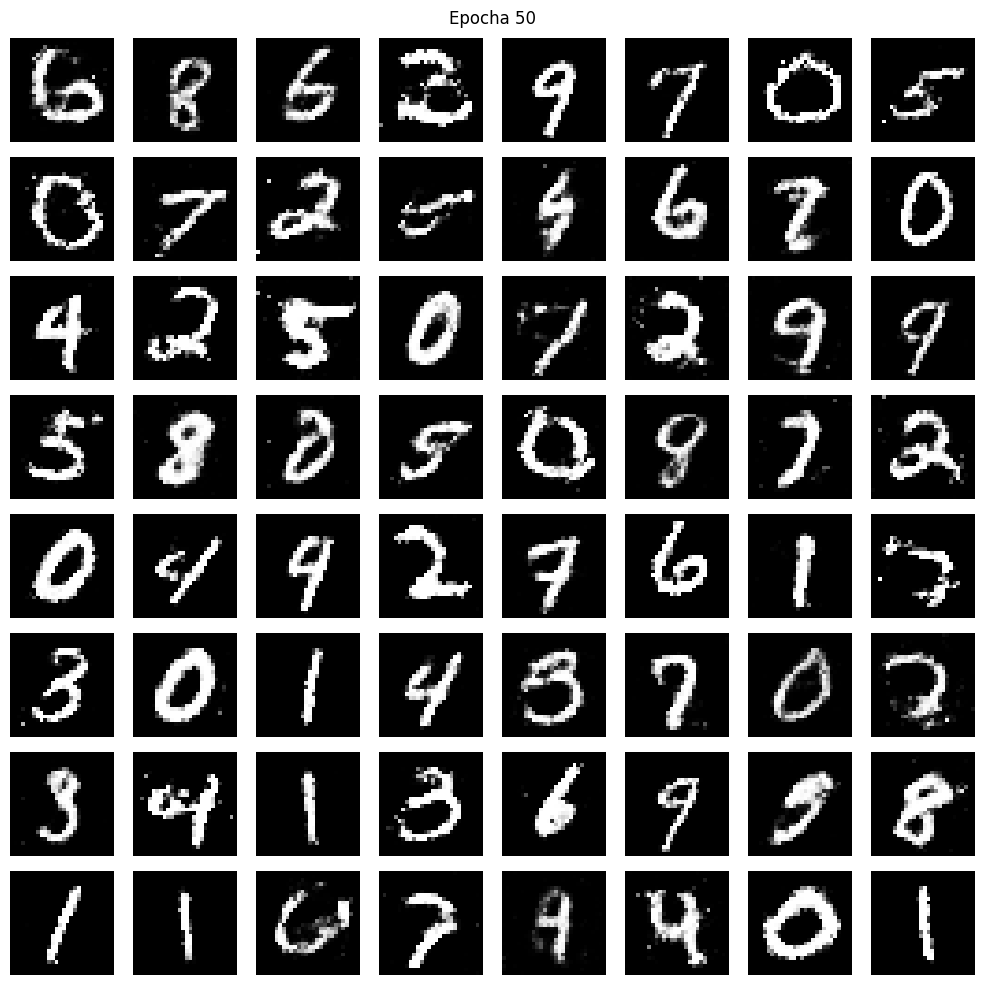

In [ ]:
def train_gan():
    g_losses = []
    d_losses = []
    d_accuracies = []

    # Fixný šum (latentne vektory) pre vizualizáciu progresu
    fixed_noise = torch.randn(64, LATENT_DIM, device=device)

    print("="*60)
    print("ZAČÍNAM TRÉNOVANIE GAN")
    print("="*60)

    for epoch in range(EPOCHS):
        epoch_g_loss = 0
        epoch_d_loss = 0
        epoch_d_acc = 0

        for i, (real_imgs, _) in enumerate(train_loader):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)

            # Labels
            real_labels = torch.ones(batch_size, 1, device=device)  # jednotky
            fake_labels = torch.zeros(batch_size, 1, device=device) # nuly

            # =====================
            # Trénuj DISKRIMINÁTOR
            # =====================
            optimizer_D.zero_grad()

            # Real images
            real_validity = discriminator(real_imgs) # diskriminator hodnoti realne obrazky
            d_real_loss = adversarial_loss(real_validity, real_labels)

            # Fake images
            z = torch.randn(batch_size, LATENT_DIM, device=device) # latentne vektory
            fake_imgs = generator(z)  # generovanie obrazkov z latentnych vektorov
            fake_validity = discriminator(fake_imgs.detach()) # diskriminator hodnoti falosne obrazky
            d_fake_loss = adversarial_loss(fake_validity, fake_labels)

            # Total discriminator loss
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            # Presnosť diskriminátora
            real_acc = (real_validity > 0.5).float().mean()
            fake_acc = (fake_validity < 0.5).float().mean()
            d_acc = (real_acc + fake_acc) / 2

            # ===================
            # Trénuj GENERÁTOR
            # ===================
            optimizer_G.zero_grad()

            z = torch.randn(batch_size, LATENT_DIM, device=device) # latentne vektory
            gen_imgs = generator(z) # generovanie obrazkov z latentnych vektorov
            validity = discriminator(gen_imgs) # diskriminator hodnoti falosne obrazky

            # Generátor chce, aby D myslel, že fake je real!
            g_loss = adversarial_loss(validity, real_labels) # pouzijeme real labels namiesto fake labels
            g_loss.backward()
            optimizer_G.step()

            # Štatistiky
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            epoch_d_acc += d_acc.item()

        # Priemerné hodnoty pre epochu
        avg_g_loss = epoch_g_loss / len(train_loader)
        avg_d_loss = epoch_d_loss / len(train_loader)
        avg_d_acc = epoch_d_acc / len(train_loader)

        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        d_accuracies.append(avg_d_acc)

        # Výpis progress
        print(f"Epocha [{epoch+1}/{EPOCHS}] | "
              f"D Loss: {avg_d_loss:.4f} | "
              f"G Loss: {avg_g_loss:.4f} | "
              f"D Acc: {avg_d_acc*100:.1f}%")

        # Vizualizácia progress každých 5 epoch
        if (epoch + 1) % 5 == 0:
            generator.eval()
            with torch.no_grad():
                fake = generator(fixed_noise)
            generator.train()

            plt.figure(figsize=(10, 10))
            for i in range(64):
                plt.subplot(8, 8, i+1)
                plt.imshow(fake[i].cpu().squeeze(), cmap='gray')
                plt.axis('off')
            plt.suptitle(f'Epocha {epoch+1}')
            plt.tight_layout()
            plt.show()

    return g_losses, d_losses, d_accuracies

# Spustenie tréningu
g_losses, d_losses, d_accuracies = train_gan()

## 6. Vizualizácia progresu tréningu

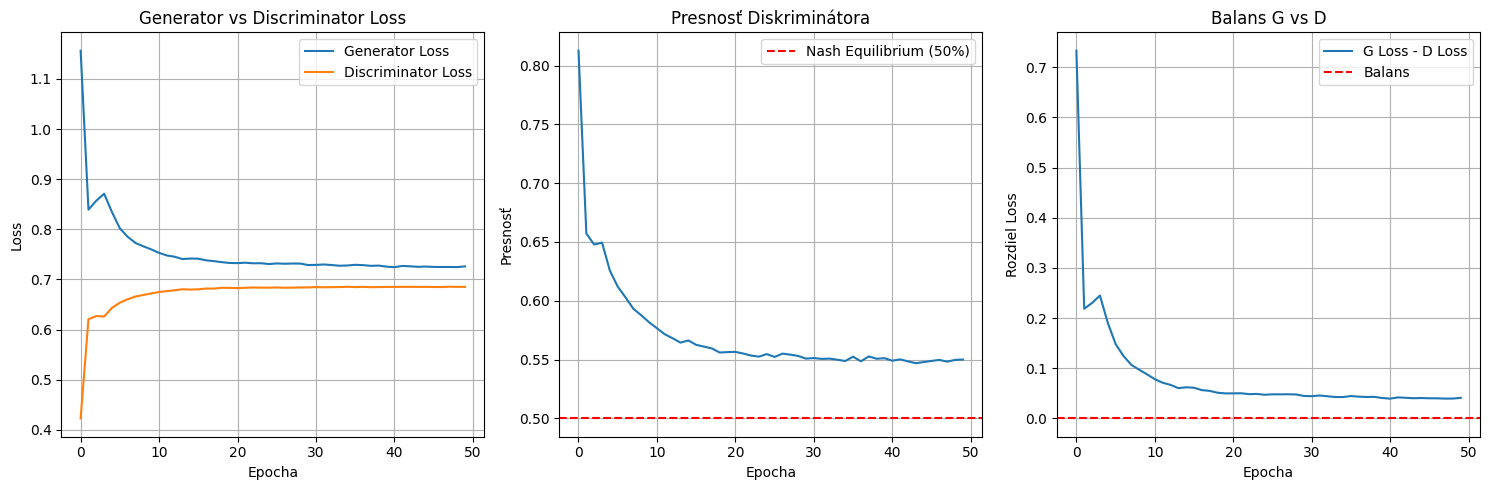

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.title('Generator vs Discriminator Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(d_accuracies)
plt.axhline(y=0.5, color='r', linestyle='--', label='Nash Equilibrium (50%)')
plt.xlabel('Epocha')
plt.ylabel('Presnosť')
plt.title('Presnosť Diskriminátora')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(np.array(g_losses) - np.array(d_losses), label='G Loss - D Loss')
plt.axhline(y=0, color='r', linestyle='--', label='Balans')
plt.xlabel('Epocha')
plt.ylabel('Rozdiel Loss')
plt.title('Balans G vs D')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Generovanie nových obrázkov

GENEROVANIE NOVÝCH OBRÁZKOV


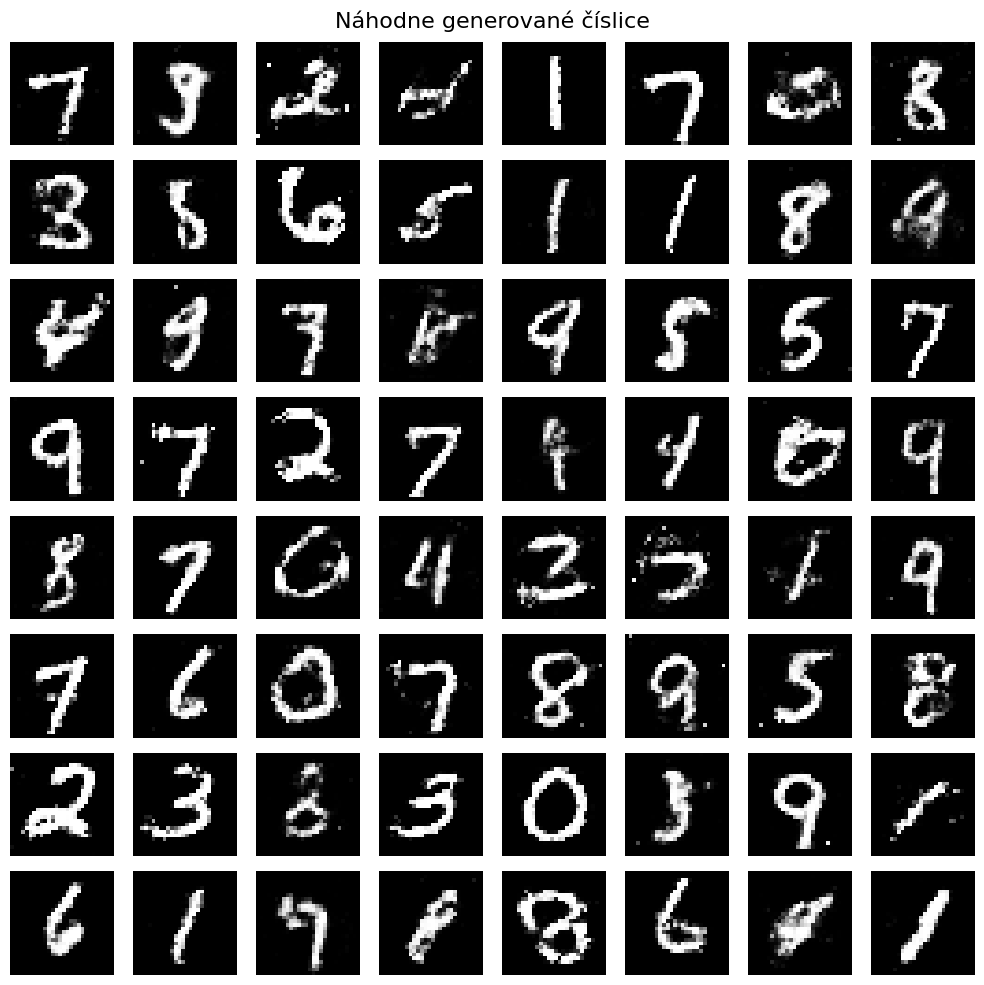

In [ ]:
print("="*60)
print("GENEROVANIE NOVÝCH OBRÁZKOV")
print("="*60)

generator.eval()
with torch.no_grad():
    z = torch.randn(64, LATENT_DIM, device=device)
    generated = generator(z)

plt.figure(figsize=(10, 10))
for i in range(64):
    plt.subplot(8, 8, i+1)
    plt.imshow(generated[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('Náhodne generované číslice', fontsize=16)
plt.tight_layout()
plt.show()

## 8. Interpolácia v latentnom priestore

INTERPOLÁCIA V LATENTNOM PRIESTORE


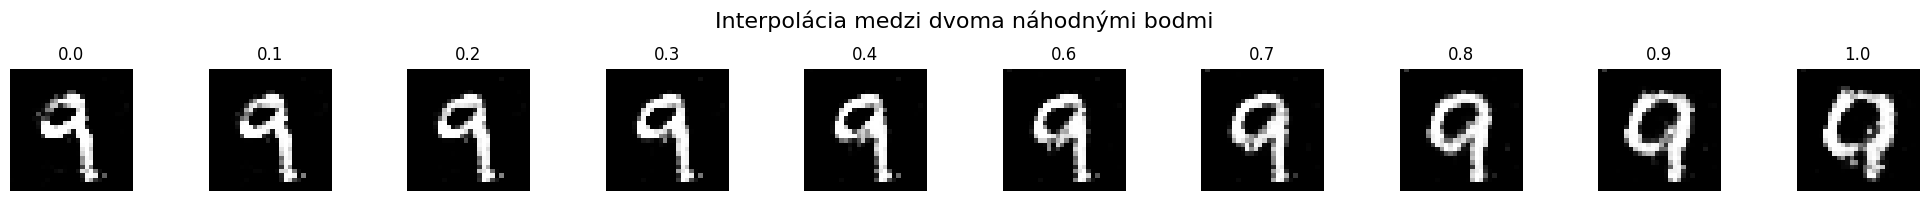

In [ ]:
print("="*60)
print("INTERPOLÁCIA V LATENTNOM PRIESTORE")
print("="*60)

generator.eval()
with torch.no_grad():
    z1 = torch.randn(1, LATENT_DIM, device=device)
    z2 = torch.randn(1, LATENT_DIM, device=device)

    steps = 10
    interpolated_imgs = []

    for alpha in np.linspace(0, 1, steps):
        z_interp = (1 - alpha) * z1 + alpha * z2 # interpolacia
        img = generator(z_interp)
        interpolated_imgs.append(img.cpu().squeeze())

    plt.figure(figsize=(20, 2))
    for i, img in enumerate(interpolated_imgs):
        plt.subplot(1, steps, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'{i/(steps-1):.1f}')
        plt.axis('off')
    plt.suptitle('Interpolácia medzi dvoma náhodnými bodmi', fontsize=16)
    plt.tight_layout()
    plt.show()

## 9. Porovnanie skutočných vs generovaných

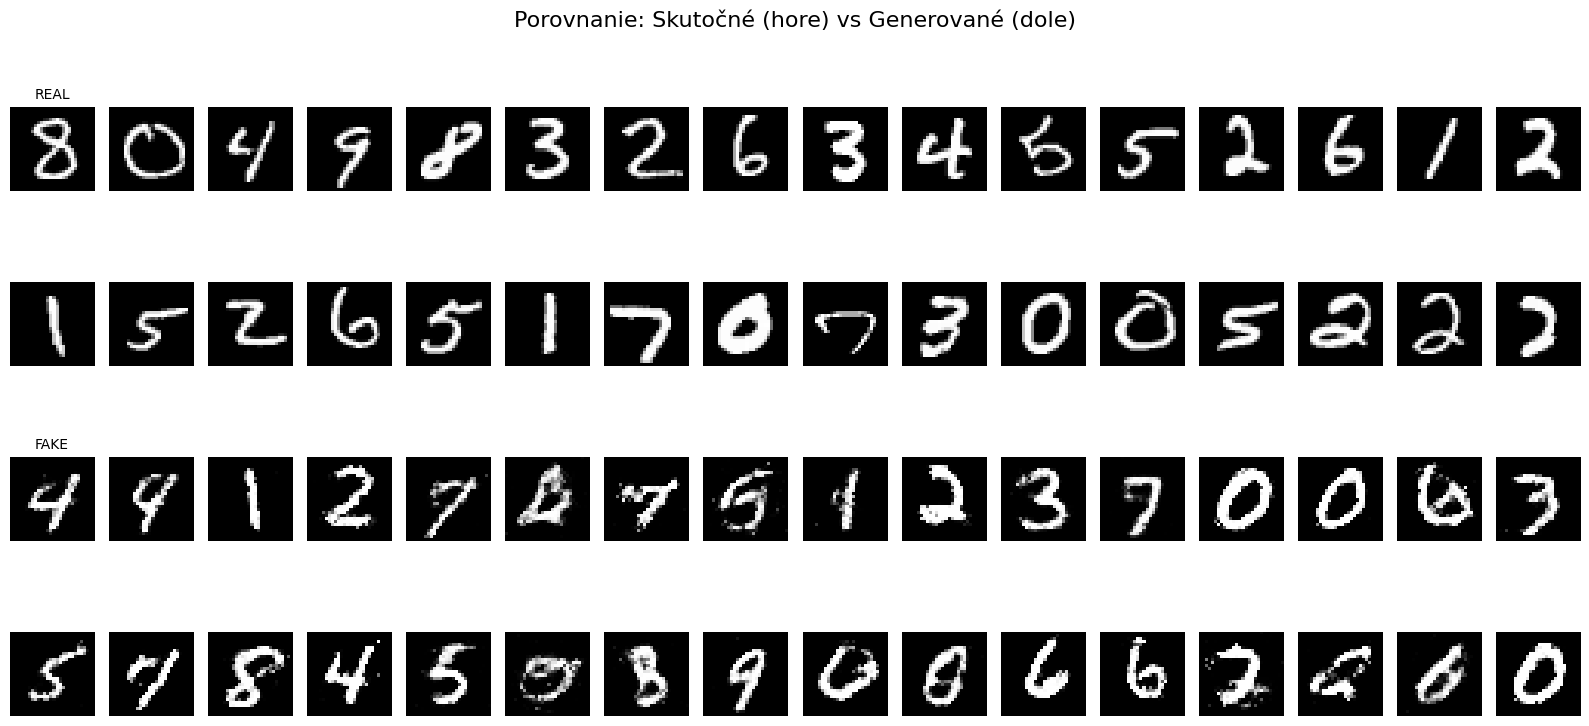

In [ ]:
# Načítame skutočné obrázky
real_imgs, _ = next(iter(train_loader))
real_imgs = real_imgs[:32]

# Vygenerujeme fake obrázky
generator.eval()
with torch.no_grad():
    z = torch.randn(32, LATENT_DIM, device=device)
    fake_imgs = generator(z)

# Vizualizácia
plt.figure(figsize=(16, 8))

# Skutočné
for i in range(32):
    plt.subplot(4, 16, i+1)
    plt.imshow(real_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('REAL', fontsize=10)

# Fake
for i in range(32):
    plt.subplot(4, 16, 32+i+1)
    plt.imshow(fake_imgs[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('FAKE', fontsize=10)

plt.suptitle('Porovnanie: Skutočné (hore) vs Generované (dole)', fontsize=16)
plt.tight_layout()
plt.show()

## Záver

**Poznámky o trénovaní GAN:**
- GAN trénovanie je **nestabilné**
- Mode collapse je častý problém
- Cieľ: D presnosť ≈ 50% (Nash equilibrium)

Vytvorené s použitím Claude AI.